## 可重复性
作者：曹明浩    时间：2026.2.15
* 4图合一

### 1. 导入Python模块

In [24]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
from scipy.stats import binned_statistic_2d
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


In [43]:
# 导入数据
source = "f"
file_path = rf'F:\03.Data\{source}14.repeatability\02.repeatability_result\bayes_variance_*_allwindow_*.parquet'
df = pl.scan_parquet(file_path).collect()
pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_rows(-1)
pl.Config.set_tbl_width_chars(400)
anova_variance = df.select(pl.col('anova_repeatability'))
bayes_variance = df.select(pl.col('bayes_repeatability'))
correlation = df.select(pl.corr('anova_repeatability','bayes_repeatability')).item()
print(f"Pearson相关系数: {correlation:.4f}")
print(df.head(15))

Pearson相关系数: 0.9303
shape: (15, 10)
┌──────┬─────────┬──────────┬──────────────────────┬────────────────────────┬─────────────────────┬───────────────┬──────────────────────┬────────────────────────┬─────────────────────┐
│ chra ┆ windowa ┆ trait_id ┆ anova_sigma_alpha_sq ┆ anova_sigma_epsilon_sq ┆ anova_repeatability ┆ anova_f_value ┆ bayes_sigma_alpha_sq ┆ bayes_sigma_epsilon_sq ┆ bayes_repeatability │
│ ---  ┆ ---     ┆ ---      ┆ ---                  ┆ ---                    ┆ ---                 ┆ ---           ┆ ---                  ┆ ---                    ┆ ---                 │
│ i64  ┆ i64     ┆ i64      ┆ f64                  ┆ f64                    ┆ f64                 ┆ f64           ┆ f64                  ┆ f64                    ┆ f64                 │
╞══════╪═════════╪══════════╪══════════════════════╪════════════════════════╪═════════════════════╪═══════════════╪══════════════════════╪════════════════════════╪═════════════════════╡
│ 10   ┆ 0       ┆ 1        ┆ 0.04

### 2. 可视化

In [44]:
def compute_bin_stats(msb, msw, repeatability, bins=20, stat_type='mean', min_samples=20):
    stat_result, xedges, yedges, _ = binned_statistic_2d(
        msb, msw, repeatability, statistic=stat_type, bins=bins)
    count_result, _, _, _ = binned_statistic_2d(
        msb, msw, repeatability, statistic='count', bins=bins)

    stat_masked = stat_result.copy()
    stat_masked[count_result < min_samples] = np.nan

    filled  = np.nan_to_num(stat_masked, nan=0.0)
    weights = (~np.isnan(stat_masked)).astype(float)
    W_smooth = gaussian_filter(weights, sigma=1.3)
    with np.errstate(divide='ignore', invalid='ignore'):
        Z_smooth = gaussian_filter(filled, sigma=1.3) / W_smooth
    Z_smooth[W_smooth == 0] = np.nan

    Xc, Yc = np.meshgrid(
        (xedges[:-1] + xedges[1:]) / 2.0,
        (yedges[:-1] + yedges[1:]) / 2.0
    )
    return dict(
        stat_masked=stat_masked, count=count_result,
        Z_smooth=Z_smooth, Xc=Xc, Yc=Yc,
        xedges=xedges, yedges=yedges,
        vmin=np.nanmin(stat_masked), vmax=np.nanmax(stat_masked)
    )

def plot_scatter(ax, fig, msb, msw, repeatability, method_name, sample_ratio=0.025):
    # ── 全量数据用于统计计算 ──────────────────────────────
    z_fit = np.polyfit(msb, msw, 1)
    msb_med, msw_med = np.median(msb), np.median(msw)
    corr = np.corrcoef(msb, msw)[0, 1]

    # ── 随机抽样仅用于绘制散点 ────────────────────────────
    n_total = len(msb)
    n_sample = max(1, int(n_total * sample_ratio))  # 至少保留1个点
    rng = np.random.default_rng(seed=42)            # 固定随机种子，保证可复现
    idx = rng.choice(n_total, size=n_sample, replace=False)

    msb_s   = msb[idx]
    msw_s   = msw[idx]
    rep_s   = repeatability[idx]

    print(f"[{method_name}] 总样本: {n_total}, 绘图抽样: {n_sample} ({sample_ratio*100:.1f}%)")

    # ── 绘图 ──────────────────────────────────────────────
    scatter = ax.scatter(msb_s, msw_s, alpha=0.6,
                         c=rep_s, cmap='viridis',
                         s=30, edgecolors='black', linewidths=0.3)
    fig.colorbar(scatter, ax=ax, pad=0.02).set_label('Repeatability', fontsize=9)

    msb_sorted = np.sort(msb)   # 趋势线仍用全量
    ax.plot(msb_sorted, np.poly1d(z_fit)(msb_sorted), 'r--', alpha=0.8, linewidth=1.5,
            label=f'Trend: y={z_fit[0]:.3f}x+{z_fit[1]:.3f}')

    ax.axvline(x=msb_med, color="#FFF387", linewidth=1.8, label=f'Median MSB: {msb_med:.3f}')
    ax.axhline(y=msw_med, color="#FF7722", linewidth=1.8, label=f'Median MSW: {msw_med:.3f}')
    ax.scatter([msb_med], [msw_med], color='red', s=80,
               marker='x', linewidths=2.5, zorder=5, label='Intersection')

    ax.text(0.05, 0.95,
            f'r = {corr:.3f}\nn = {n_total:,} (plot: {n_sample:,})',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))

    ax.set_xlabel('MSB (between groups)', fontsize=9)
    ax.set_ylabel('MSW (within groups)', fontsize=9)
    ax.set_title(f'[{method_name}] Scatter: MSB vs MSW', fontsize=10)
    ax.legend(fontsize=7, loc='lower right')

def plot_density(ax, fig, bs, method_name):
    pcm = ax.pcolormesh(bs['xedges'], bs['yedges'], bs['count'].T, shading='auto')
    fig.colorbar(pcm, ax=ax, pad=0.02, label='count')
    ax.set_title(f'[{method_name}] Sample Count per Bin', fontsize=10)
    ax.set_xlabel('MSB', fontsize=9); ax.set_ylabel('MSW', fontsize=9)

def plot_heatmap(ax, fig, bs, method_name, stat_type='mean', bins=20):
    pcm = ax.pcolormesh(bs['xedges'], bs['yedges'], bs['stat_masked'].T,
                        shading='auto', cmap='viridis',
                        vmin=bs['vmin'], vmax=bs['vmax'])
    fig.colorbar(pcm, ax=ax, pad=0.02, label=f'Repeatability ({stat_type})')
    ax.set_title(f'[{method_name}] 2D Heatmap (bins={bins})', fontsize=10)
    ax.set_xlabel('MSB', fontsize=9); ax.set_ylabel('MSW', fontsize=9)

def plot_3d(ax, fig, bs, method_name, stat_type='mean'):
    # 从已有的bin中心点提取有效数据
    Xc_flat = bs['Xc'].ravel()
    Yc_flat = bs['Yc'].ravel()
    Z_flat  = bs['Z_smooth'].T.ravel()  # 注意转置对齐

    # 去掉NaN点
    valid = ~np.isnan(Z_flat)
    xi = Xc_flat[valid]
    yi = Yc_flat[valid]
    zi = Z_flat[valid]

    # 建立更密的插值网格（分辨率可调）
    grid_res = 200  # 200×200的细密网格，曲面更平滑
    xi_grid = np.linspace(xi.min(), xi.max(), grid_res)
    yi_grid = np.linspace(yi.min(), yi.max(), grid_res)
    Xi, Yi  = np.meshgrid(xi_grid, yi_grid)

    # 插值
    Zi = griddata((xi, yi), zi, (Xi, Yi), method='cubic')

    surf = ax.plot_surface(Xi, Yi, Zi,
                           cmap='viridis',
                           vmin=bs['vmin'], vmax=bs['vmax'],
                           linewidth=0, antialiased=True,
                           rasterized=True)  # ← 关键：光栅化曲面
    fig.colorbar(surf, ax=ax, shrink=0.4, pad=0.08,
                 label=f'Repeatability ({stat_type})').ax.tick_params(labelsize=4)
    ax.set_xlabel('MSB', fontsize=5); ax.set_ylabel('MSW', fontsize=5)
    ax.set_zlabel('Repeatability', fontsize=5)
    ax.set_title(f'[{method_name}] 3D Surface', fontsize=6)
    ax.tick_params(labelsize=4)


In [45]:
# ══════════════════════════════════════════════════════════
# 数据准备
# ══════════════════════════════════════════════════════════
df_pd = df.to_pandas()

b_msb = df_pd['bayes_sigma_alpha_sq'].to_numpy()
b_msw = df_pd['bayes_sigma_epsilon_sq'].to_numpy()
b_rep = df_pd['bayes_repeatability'].to_numpy()

a_msb = df_pd['anova_sigma_alpha_sq'].to_numpy()
a_msw = df_pd['anova_sigma_epsilon_sq'].to_numpy()
a_rep = df_pd['anova_repeatability'].to_numpy()

bins, stat_type, min_samples = 20, 'mean', 20
bs_bayes = compute_bin_stats(b_msb, b_msw, b_rep, bins, stat_type, min_samples)
bs_anova = compute_bin_stats(a_msb, a_msw, a_rep, bins, stat_type, min_samples)


[Bayes] 总样本: 269535, 绘图抽样: 2695 (1.0%)
[ANOVA] 总样本: 269535, 绘图抽样: 2695 (1.0%)


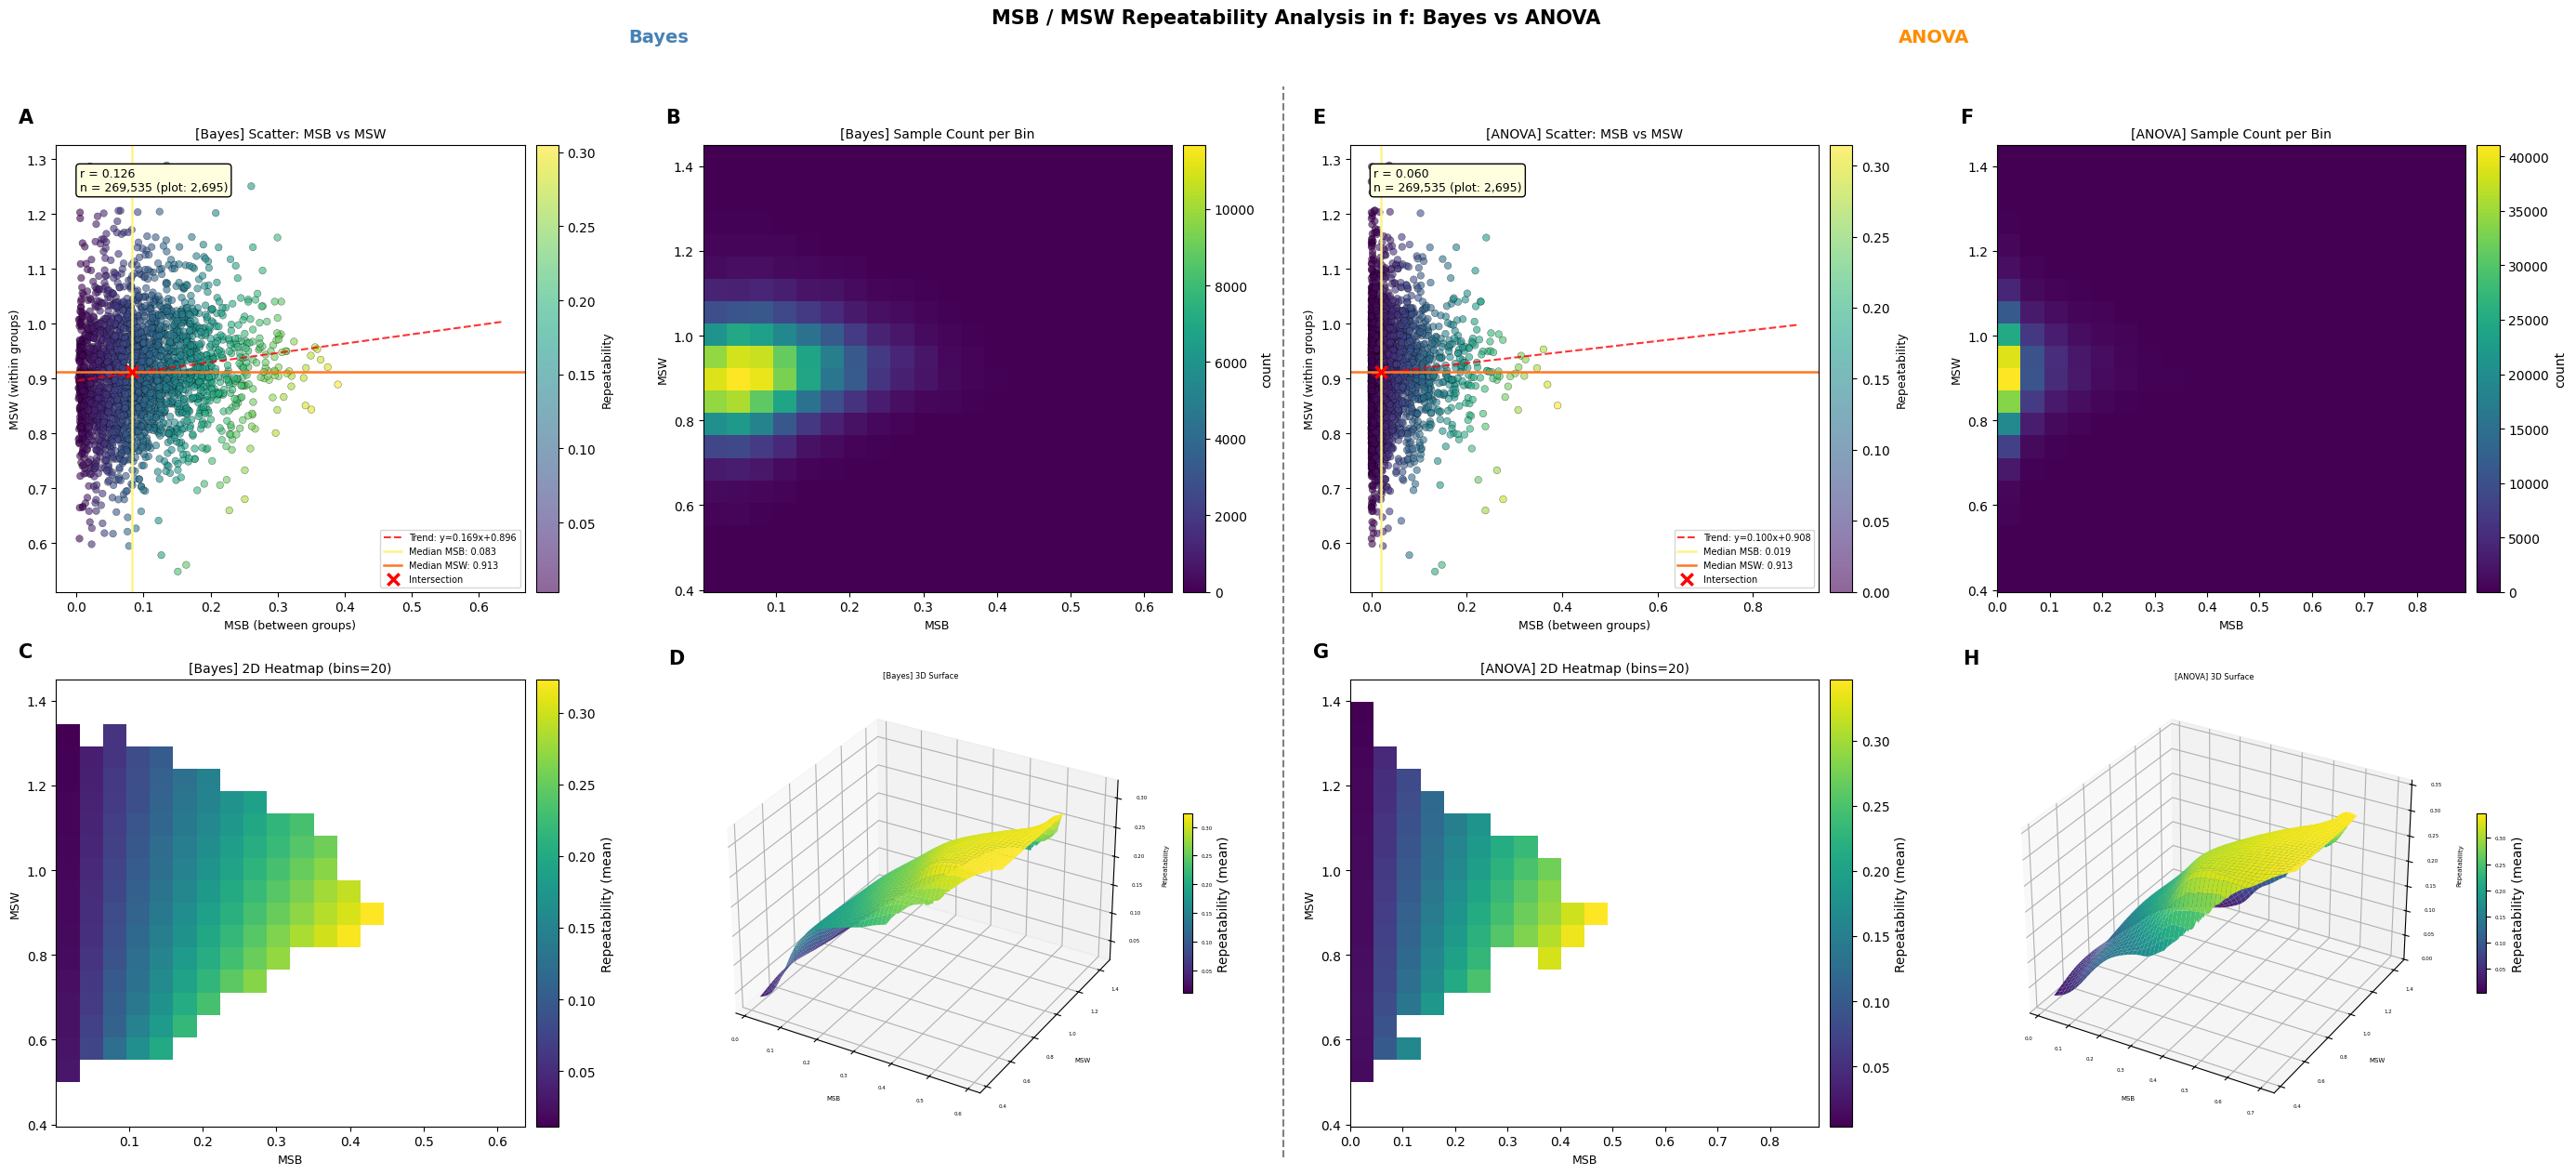

In [46]:
# ══════════════════════════════════════════════════════════
# 创建 2×4 画布
# 位置编号对应关系（行优先 1~8）：
#   1=A  2=B  3=E  4=F
#   5=C  6=D  7=G  8=H
# ══════════════════════════════════════════════════════════
fig = plt.figure(figsize=(28, 12))

ax_A = fig.add_subplot(2, 4, 1)                  # 第1行第1列 → A 散点 Bayes
ax_B = fig.add_subplot(2, 4, 2)                  # 第1行第2列 → B 密度 Bayes
ax_E = fig.add_subplot(2, 4, 3)                  # 第1行第3列 → E 散点 ANOVA
ax_F = fig.add_subplot(2, 4, 4)                  # 第1行第4列 → F 密度 ANOVA

ax_C = fig.add_subplot(2, 4, 5)                  # 第2行第1列 → C 热力 Bayes
ax_D = fig.add_subplot(2, 4, 6, projection='3d') # 第2行第2列 → D 3D   Bayes
ax_G = fig.add_subplot(2, 4, 7)                  # 第2行第3列 → G 热力 ANOVA
ax_H = fig.add_subplot(2, 4, 8, projection='3d') # 第2行第4列 → H 3D   ANOVA

# ── 绘图 ──────────────────────────────────────────────────
plot_scatter(ax_A, fig, b_msb, b_msw, b_rep, 'Bayes', sample_ratio=0.01)
plot_density(ax_B, fig, bs_bayes, 'Bayes')
plot_scatter(ax_E, fig, a_msb, a_msw, a_rep, 'ANOVA', sample_ratio=0.01)
plot_density(ax_F, fig, bs_anova, 'ANOVA')

plot_heatmap(ax_C, fig, bs_bayes, 'Bayes', stat_type, bins)
plot_3d     (ax_D, fig, bs_bayes, 'Bayes', stat_type)
plot_heatmap(ax_G, fig, bs_anova, 'ANOVA', stat_type, bins)
plot_3d     (ax_H, fig, bs_anova, 'ANOVA', stat_type)

# ── 子图编号 ABCDEFGH ─────────────────────────────────────
label_order = [
    (ax_A, 'A'), (ax_B, 'B'), (ax_E, 'E'), (ax_F, 'F'),
    (ax_C, 'C'), (ax_D, 'D'), (ax_G, 'G'), (ax_H, 'H'),
]
for ax, label in label_order:
    if hasattr(ax, 'text2D'):   # 3D轴
        ax.text2D(-0.08, 1.05, label, transform=ax.transAxes,
                  fontsize=15, fontweight='bold')
    else:
        ax.text(-0.08, 1.05, label, transform=ax.transAxes,
                fontsize=15, fontweight='bold')

# ── 列组标题（顶部）──────────────────────────────────────
# Bayes 居中于第1、2列，ANOVA 居中于第3、4列
fig.text(0.255, 1.02, 'Bayes', ha='center', fontsize=14,
         fontweight='bold', color='steelblue')
fig.text(0.745, 1.02, 'ANOVA', ha='center', fontsize=14,
         fontweight='bold', color='darkorange')

# ── 分隔线（Bayes / ANOVA 之间）──────────────────────────
fig.add_artist(plt.Line2D([0.495, 0.495], [0.02, 0.98],
                           transform=fig.transFigure,
                           color='gray', linewidth=1.5, linestyle='--'))


# ── 总标题 ────────────────────────────────────────────────
fig.suptitle(f'MSB / MSW Repeatability Analysis in {source}: Bayes vs ANOVA',
             fontsize=15, fontweight='bold', y=1.05)

plt.tight_layout()
plot_path_combined = rf'D:\02.File\2025-2026学年第2学期\02.文章\2026.3.28\01.代码直出\2026.4.2.{source}_repearability_analysis.pdf'
plt.savefig(plot_path_combined, format='pdf', dpi=300, bbox_inches='tight')
plt.show()